In [1]:
import os
from PIL import Image

# Create output folder
os.makedirs("resized_images", exist_ok=True)

# Image paths
image_paths = [
    "images1.jpg",
    "images2.jpg",
    "images3.jpg"
]

# Resize images
for path in image_paths:

    image = Image.open(path)

    resized = image.resize((224, 224))

    filename = os.path.basename(path)

    save_path = os.path.join("resized_images", filename)

    resized.save(save_path)

    print(f"Saved: {save_path}")

print("\nAll images resized successfully.")

Saved: resized_images\images1.jpg
Saved: resized_images\images2.jpg
Saved: resized_images\images3.jpg

All images resized successfully.


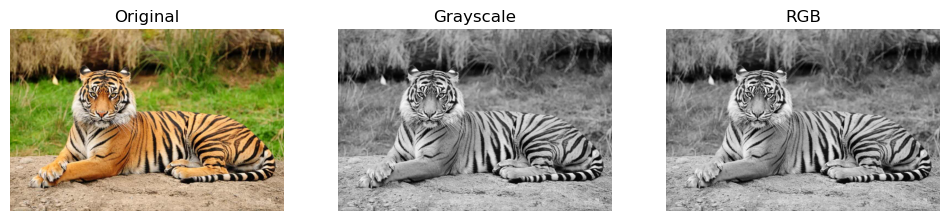

In [3]:
import matplotlib.pyplot as plt

# Load Image
image = Image.open("images1.jpg")

# Convert to Grayscale
gray = image.convert("L")

# Convert Grayscale back to RGB
rgb = gray.convert("RGB")

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.show()

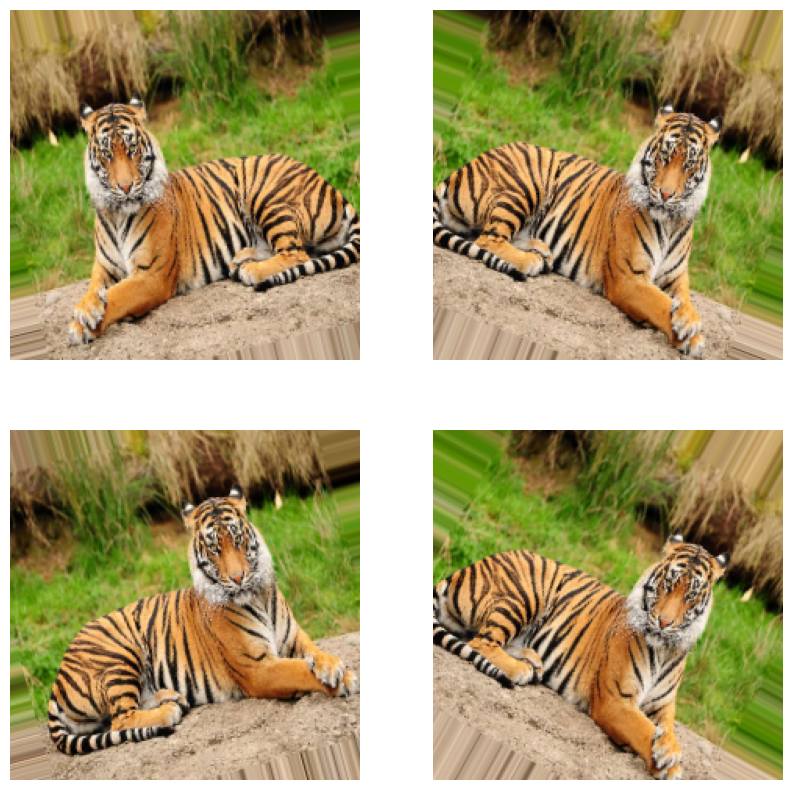

In [5]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

# Load Image
image = load_img("images1.jpg", target_size=(224,224))

image = img_to_array(image)

image = np.expand_dims(image, axis=0)

# ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True
)

# Generate Images
plt.figure(figsize=(10,10))

i = 0

for batch in datagen.flow(image, batch_size=1):

    plt.subplot(2,2,i+1)

    plt.imshow(batch[0].astype("uint8"))

    plt.axis("off")

    i += 1

    if i == 4:
        break

plt.show()

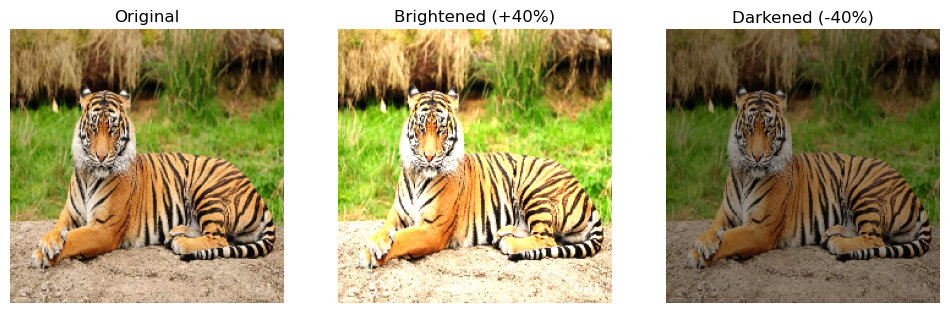

In [6]:

# Load Image
image = load_img("images1.jpg", target_size=(224,224))

image = img_to_array(image)

image = np.expand_dims(image, axis=0)

# Bright Image Generator
bright_gen = ImageDataGenerator(
    brightness_range=[1.4,1.4]
)

# Dark Image Generator
dark_gen = ImageDataGenerator(
    brightness_range=[0.6,0.6]
)

bright = next(bright_gen.flow(image, batch_size=1))[0].astype("uint8")

dark = next(dark_gen.flow(image, batch_size=1))[0].astype("uint8")

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image[0].astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bright)
plt.title("Brightened (+40%)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(dark)
plt.title("Darkened (-40%)")
plt.axis("off")

plt.show()

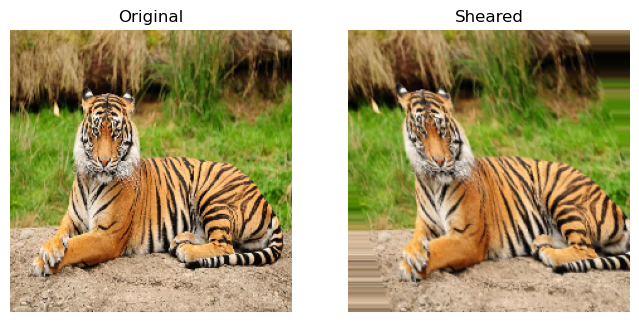

Observation:
The shear transformation slants the image, making objects appear tilted while preserving most of their visual features.


In [7]:

# Load Image
image = load_img("images1.jpg", target_size=(224,224))

image = img_to_array(image)

image = np.expand_dims(image, axis=0)

# Shear Generator
datagen = ImageDataGenerator(
    shear_range=25
)

# Generate Sheared Image
sheared = next(datagen.flow(image, batch_size=1))[0].astype("uint8")

# Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image[0].astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sheared)
plt.title("Sheared")
plt.axis("off")

plt.show()

print("Observation:")
print("The shear transformation slants the image, making objects appear tilted while preserving most of their visual features.")